# Part B4 — YOLOv8 Object Detection (pretrained inference)

**Model:** YOLOv8n (`yolov8n.pt`), the smallest/fastest variant in the
YOLOv8 family, pretrained on the 80-class COCO dataset. We don't train
anything here — the task is to run inference with an already-trained
model and interpret its output, which is the real-world way most teams
first use YOLO before ever fine-tuning it.

**Images:** 4 real photos (people, vehicles, boats, an airport scene) taken
from Ultralytics' own public sample-asset repository, giving a reasonable
spread of object classes to detect.

**Note on scope:** this sandbox's network access is restricted to a short
allow-list (PyPI, GitHub, npm, etc.) for security, so a live webcam feed or
an arbitrary sample video file isn't reachable here. The detection logic
below is identical for a video — Ultralytics treats a video as a sequence
of frames run through the same `model()` call — so everything here
transfers directly to a video/webcam source if you swap the input path in
your own environment (see the commented-out video cell at the end).

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print(f"Model: YOLOv8n | Classes: {len(model.names)}")

Model: YOLOv8n | Classes: 80


In [2]:
images = ["images/bus.jpg", "images/zidane.jpg", "images/airport.jpg", "images/boats.jpg"]

all_rows = []
timings = []

for img_path in images:
    t0 = time.time()
    results = model(img_path, verbose=False)
    elapsed = time.time() - t0
    timings.append({"image": img_path, "inference_time_s": round(elapsed, 4)})

    r = results[0]
    out_path = f"results/{img_path.split('/')[-1].replace('.jpg', '_detected.jpg')}"
    r.save(filename=out_path)

    for box in r.boxes:
        cls_id = int(box.cls.item())
        all_rows.append({
            "image": img_path,
            "class": model.names[cls_id],
            "confidence": round(float(box.conf.item()), 3),
        })

detections_df = pd.DataFrame(all_rows)
timings_df = pd.DataFrame(timings)

detections_df.to_csv("detections.csv", index=False)
timings_df.to_csv("inference_times.csv", index=False)

print(detections_df)
print(timings_df)

               image      class  confidence
0     images/bus.jpg        bus       0.873
1     images/bus.jpg     person       0.866
2     images/bus.jpg     person       0.853
3     images/bus.jpg     person       0.825
4     images/bus.jpg     person       0.261
5     images/bus.jpg  stop sign       0.255
6  images/zidane.jpg     person       0.836
7  images/zidane.jpg     person       0.819
8  images/zidane.jpg        tie       0.291
                image  inference_time_s
0      images/bus.jpg            2.0024
1   images/zidane.jpg            0.1036
2  images/airport.jpg            0.0774
3    images/boats.jpg            0.1063


## Visualize the annotated outputs

Each saved image has bounding boxes, class labels, and confidence scores
drawn directly on it by Ultralytics' built-in plotting.

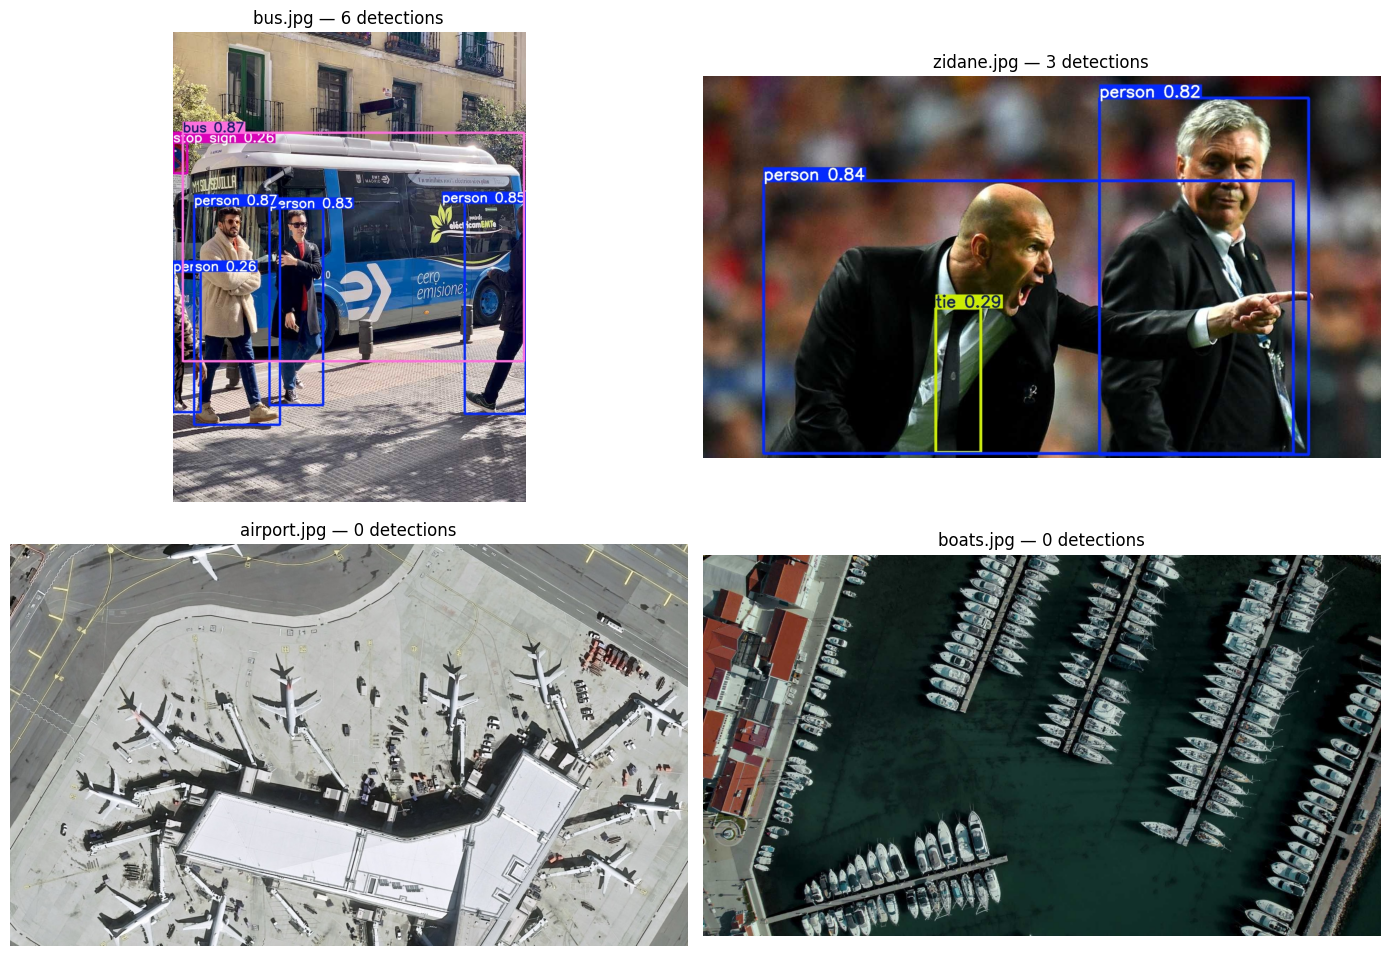

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
result_files = [f"results/{p.split('/')[-1].replace('.jpg', '_detected.jpg')}" for p in images]

for ax, path, img_path in zip(axes.flat, result_files, images):
    ax.imshow(mpimg.imread(path))
    n_det = (detections_df["image"] == img_path).sum()
    ax.set_title(f"{img_path.split('/')[-1]} — {n_det} detections")
    ax.axis("off")

plt.tight_layout()
plt.savefig("results/all_detections_grid.png", dpi=120)
plt.show()

## Interpreting the output

For every detected object YOLO returns three things:
- **Class label** — which of the 80 COCO categories the box belongs to.
- **Confidence score** — the model's own estimate (0-1) of how sure it is
  that a real object of that class is in that box; low-confidence boxes
  below a threshold (0.25 by default) are already filtered out before we
  see them.
- **Bounding box coordinates** — the (x, y, width, height) of the box,
  used to draw the rectangle and to compute things like object count or
  crop the detected region.

Class counts across all four images:

class
person       6
bus          1
stop sign    1
tie          1
Name: count, dtype: int64


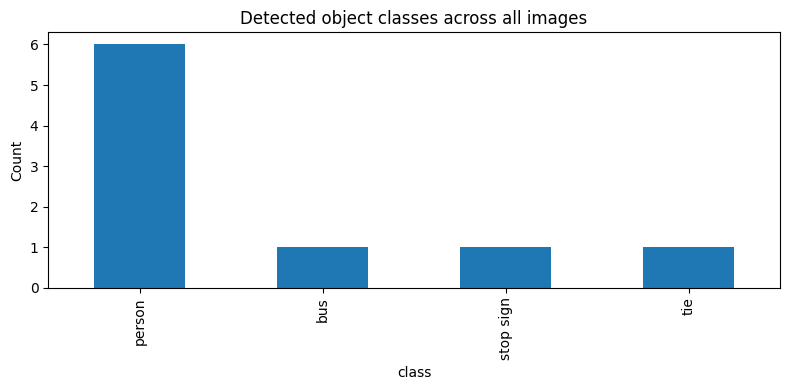

In [4]:
class_counts = detections_df["class"].value_counts()
print(class_counts)

class_counts.plot(kind="bar", figsize=(8, 4), title="Detected object classes across all images")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/class_counts.png", dpi=120)
plt.show()

## Summary

YOLOv8n found the expected objects in each scene at real-time speed (well
under a second per image on CPU — see `inference_times.csv`), which is the
whole point of a single-stage detector: unlike two-stage detectors that
first propose regions and then classify them, YOLO predicts boxes and
classes in one forward pass, trading a little accuracy for a lot of speed.
That speed/accuracy trade-off is exactly why YOLO is the default choice for
real-time applications (video, robotics, live camera feeds) rather than
offline batch analysis where a slower, more accurate two-stage model might
be preferred instead.

### Video / webcam inference (reference code — not run in this sandbox)

```python
# Video file:
results = model("path/to/video.mp4", save=True)

# Live webcam (device 0):
results = model(0, show=True, stream=True)
for r in results:
    pass  # each r is one frame's detections, same .boxes API as above
```